In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [2]:
def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

In [3]:

def implied_vol(price_mkt, S, K, r, T, option="call", brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100):

    # Verificación de límites teóricos: el precio debe estar entre [intrínseco, cota superior]
    if option == "call":
        lower = max(0.0, S - K*np.exp(-r*T))
        upper = S
    else:
        lower = max(0.0, K*np.exp(-r*T) - S)
        upper = K*np.exp(-r*T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio de mercado fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    # Función objetivo
    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    # Ajusta el extremo superior si no cambia de signo (intenta ampliar)
    if fa*fb > 0:
        # intenta expandir b
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa*fb <= 0:
                b = b_try
                break

    # Intenta Brent
    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    # Si Brent falla, intenta método de Newton
    seed = min(max(sigma_hist if 'sigma_hist' in globals() and np.isfinite(sigma_hist) else 0.2, 1e-3), 2.0)
    try:
        iv = newton(lambda s: f(s), seed, fprime=lambda s: bs_vega(S, K, r, T, s), tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar una volatilidad implícita con los métodos intentados.")




In [4]:
ticker = 'SPY'

tk    = yf.Ticker(ticker)
exp = '2026-04-17'
today  = date.today()

data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']
S0 = float(data.iloc[-1])
r     = 0.042
K     = 680
T     = (date.fromisoformat(exp) - date.today()).days / 365

# solo informativo
daily_returns = data.pct_change().dropna()
sigma_hist = float(daily_returns.std() * np.sqrt(252))


# Precio mid: promedio de bid y ask, más estable que el último trade
chain    = tk.option_chain(exp).calls
row      = chain[chain['strike'] == K].iloc[0]
C_market = (row['bid'] + row['ask']) / 2

print(f"S0={S0:.2f} | bid={row['bid']:.2f} ask={row['ask']:.2f} mid={C_market:.4f}")


S0=648.57 | bid=3.68 ask=3.73 mid=3.7050


In [5]:
iv = implied_vol(C_market, S0, K, r, T, option="call")

bs_check = bs_price(S0, K, r, T, iv, option="call")
error    = abs(bs_check - C_market)

print(f"IV :        {iv:.4%}")
print(f"BS, C (IV): {bs_check:.6f}")
print(f"C_market     :{C_market:.6f}")

IV :        18.9511%
BS, C (IV): 3.705000
C_market     :3.705000


In [7]:
from scipy.interpolate import griddata

expirations = tk.options        
today_date  = date.today()

records = []
for exp_date in expirations:
    try:
        T_exp = (date.fromisoformat(exp_date) - today_date).days / 365
        if T_exp <= 0:
            continue

        calls = tk.option_chain(exp_date).calls
        # Filtrar strikes razonables (±30% del spot)
        calls = calls[(calls['strike'] >= S0 * 0.70) &
                      (calls['strike'] <= S0 * 1.30)]

        for _, row in calls.iterrows():
            bid, ask = row['bid'], row['ask']
            if bid <= 0 or ask <= 0:
                continue
            mid = (bid + ask) / 2
            K_i = row['strike']
            try:
                iv_i = implied_vol(mid, S0, K_i, r, T_exp, option="call")
                if 0.01 < iv_i < 5.0:         
                    records.append({
                        'exp':  exp_date,
                        'days': round(T_exp * 365),
                        'K':    K_i,
                        'IV':   iv_i
                    })
            except Exception:
                continue
    except Exception:
        continue

df_surf = pd.DataFrame(records)
print(f"Puntos en la superficie: {len(df_surf)}")
print(df_surf.head())

Puntos en la superficie: 3112
          exp  days      K        IV
0  2026-03-23     2  500.0  1.991233
1  2026-03-23     2  600.0  0.767110
2  2026-03-23     2  615.0  0.582637
3  2026-03-23     2  628.0  0.426518
4  2026-03-23     2  631.0  0.395700


In [8]:
ki  = np.linspace(df_surf['K'].min(),    df_surf['K'].max(),    60)
ti  = np.linspace(df_surf['days'].min(), df_surf['days'].max(), 60)
KK, TT  = np.meshgrid(ki, ti)
IV_grid = griddata(
    (df_surf['K'], df_surf['days']), df_surf['IV'],
    (KK, TT), method='linear'
)

Puntos válidos: 732


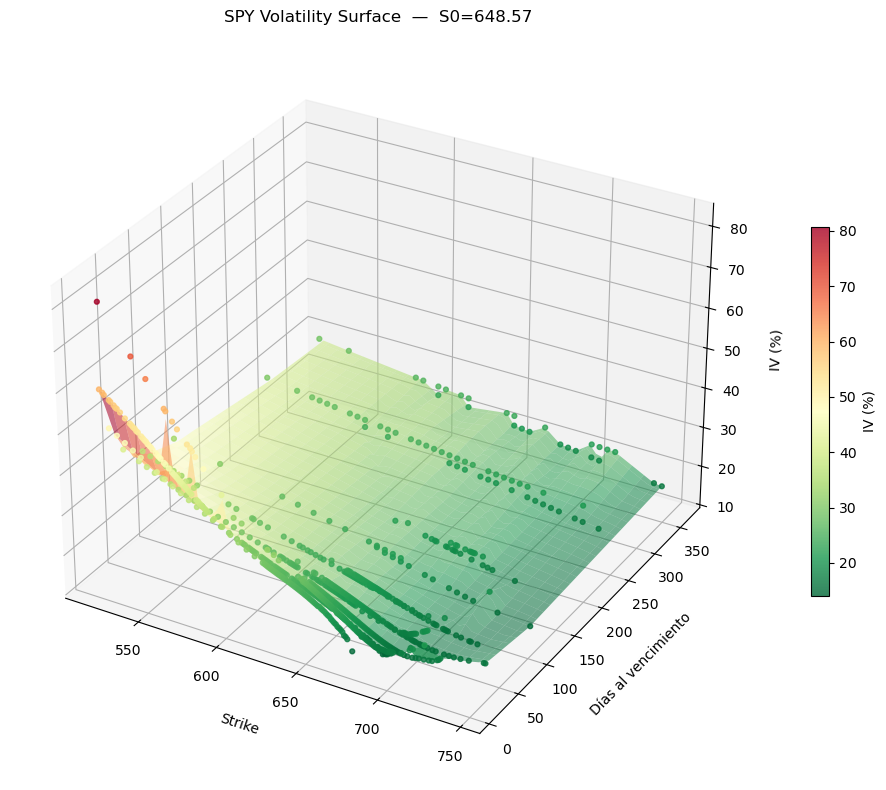

In [9]:

all_exps = [(e, (date.fromisoformat(e) - today).days)
            for e in tk.options
            if 7 <= (date.fromisoformat(e) - today).days <= 400]

# 8 vencimientos espaciados uniformemente entre 7 y 400 días
idx  = np.linspace(0, len(all_exps) - 1, min(8, len(all_exps)), dtype=int)
exps = [all_exps[i][0] for i in idx]

records = []

for exp in exps:
    T = (date.fromisoformat(exp) - today).days / 365

    # Calls y puts
    calls = tk.option_chain(exp).calls.copy()
    puts  = tk.option_chain(exp).puts.copy()

    for df, opt_type in [(calls, "call"), (puts, "put")]:
        # Filtros de liquidez y spread
        df = df[
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['volume'].fillna(0) > 50) &
            (df['ask'] / df['bid'] < 3.0) &
            (df['strike'] >= S0 * 0.80) &
            (df['strike'] <= S0 * 1.15)
        ].copy()
        df['mid'] = (df['bid'] + df['ask']) / 2

        for _, row in df.iterrows():
            K   = row['strike']
            mid = row['mid']
            try:
                iv = implied_vol(mid, S0, K, r, T, option=opt_type)
                if 0.05 <= iv <= 2.0:   # descarta IVs absurdas
                    records.append({
                        'expiry'  : exp,
                        'days'    : round(T * 365),
                        'K'       : K,
                        'moneyness': K / S0,
                        'type'    : opt_type,
                        'IV'      : iv * 100
                    })
            except Exception:
                pass

df_surf = pd.DataFrame(records)
print(f"Puntos válidos: {len(df_surf)}")

# Plot 3D
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_surf['K'],
    df_surf['days'],
    df_surf['IV'],
    c=df_surf['IV'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.8
)

# Superficie interpolada encima de los puntos
from scipy.interpolate import griddata

ki   = np.linspace(df_surf['K'].min(),    df_surf['K'].max(),    60)
ti   = np.linspace(df_surf['days'].min(), df_surf['days'].max(), 60)
KK, TT = np.meshgrid(ki, ti)
IV_grid = griddata(
    (df_surf['K'], df_surf['days']),
    df_surf['IV'],
    (KK, TT),
    method='linear'
)

ax.plot_surface(KK, TT, IV_grid, cmap='RdYlGn_r', alpha=0.55, linewidth=0)

ax.set_xlabel('Strike',              labelpad=10)
ax.set_ylabel('Días al vencimiento', labelpad=10)
ax.set_zlabel('IV (%)',              labelpad=10)
ax.set_title(f'{ticker} Volatility Surface  —  S0={S0:.2f}', pad=15)

fig.colorbar(scatter, ax=ax, shrink=0.5, label='IV (%)')
plt.tight_layout()
plt.show()

## **Actividad**

S0 = 648.57 | T = 0.0740 años | sigma_hist = 17.7713%

Strikes disponibles en rango [571, 713]: 95
Strikes con IV calculada: 95

  Volatility Skew — SPY  |  Exp: 2026-04-17  |  S0 = 648.57
 Strike   Bid   Ask    Mid  IV (%)
  575.0 77.85 80.62 79.235 38.9501
  580.0 73.14 75.92 74.530 37.7678
  585.0 68.47 71.27 69.870 36.6292
  590.0 63.95 66.66 65.305 35.6409
  595.0 59.32 62.11 60.715 34.4835
  600.0 54.82 57.56 56.190 33.3705
  605.0 50.42 53.18 51.800 32.4252
  610.0 46.09 48.90 47.495 31.5045
  615.0 41.96 44.69 43.325 30.6775
  620.0 37.77 40.54 39.155 29.6742
  625.0 33.86 36.60 35.230 28.9043
  627.0 32.33 35.05 33.690 28.5863
  628.0 31.48 34.29 32.885 28.3579
  629.0 30.73 33.53 32.130 28.2015
  630.0 30.64 32.68 31.660 28.4856
  631.0 29.21 32.02 30.615 27.8536
  634.0 28.13 29.66 28.895 28.1083
  635.0 26.63 28.74 27.685 27.2015
  636.0 26.70 28.25 27.475 27.8015
  637.0 25.91 26.44 26.175 26.7502
  638.0 24.40 25.74 25.070 25.9889
  639.0 23.79 25.04 24.415 25.8913
  640.

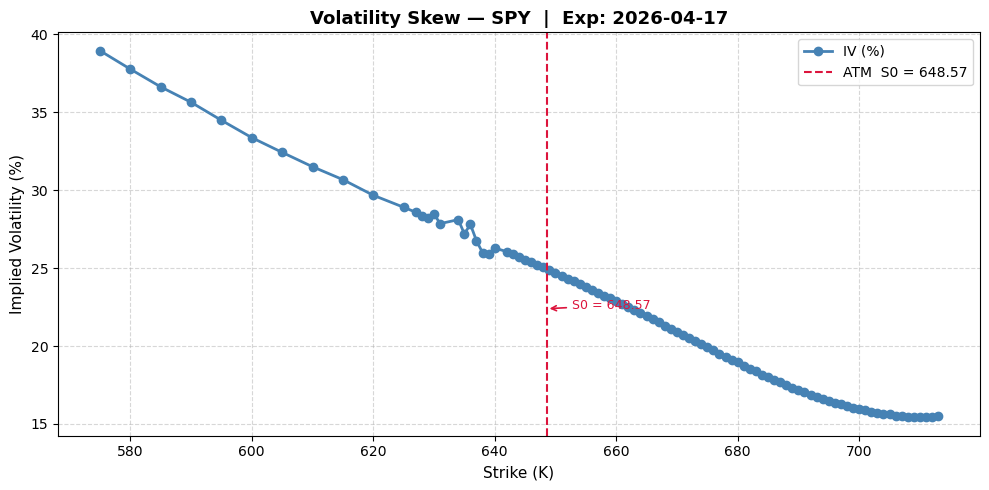

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton

# 1. Datos dinámicos 
ticker = 'SPY'
exp = '2026-04-17'
r = 0.042

tk = yf.Ticker(ticker)
today  = date.today()

data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']
S0 = float(data.iloc[-1])
T = (date.fromisoformat(exp) - today).days / 365

daily_returns = data.pct_change().dropna()
sigma_hist = float(daily_returns.std() * np.sqrt(252))

print(f"S0 = {S0:.2f} | T = {T:.4f} años | sigma_hist = {sigma_hist:.4%}")

# 2. Selección de strikes: ≥10 en rango [S0×0.88, S0×1.10]
calls_chain = tk.option_chain(exp).calls

K_min = S0 * 0.88
K_max = S0 * 1.10

# Filtrar strikes disponibles en el rango pedido
calls_filtered = calls_chain[
    (calls_chain['strike'] >= K_min) &
    (calls_chain['strike'] <= K_max) &
    (calls_chain['bid']    >  0)     &
    (calls_chain['ask']    >  0)
].copy()

print(f"\nStrikes disponibles en rango [{K_min:.0f}, {K_max:.0f}]: {len(calls_filtered)}")

# ── 3. Calcular IV para cada strike ────────────────────────────────────────
records = []

for _, row in calls_filtered.iterrows():
    K_i = row['strike']
    bid_i = row['bid']
    ask_i = row['ask']
    mid_i = (bid_i + ask_i) / 2

    try:
        iv_i = implied_vol(mid_i, S0, K_i, r, T, option="call")
        if 0.01 < iv_i < 5.0:
            records.append({
                'Strike': K_i,
                'Bid':    round(bid_i, 4),
                'Ask':    round(ask_i, 4),
                'Mid':    round(mid_i, 4),
                'IV (%)': round(iv_i * 100, 4)
            })
    except Exception:
        continue

df_skew = pd.DataFrame(records).sort_values('Strike').reset_index(drop=True)
print(f"Strikes con IV calculada: {len(df_skew)}")

# 4. Tabla Strike | Bid | Ask | Mid | IV (%) 
print("\n" + "="*60)
print(f"  Volatility Skew — {ticker}  |  Exp: {exp}  |  S0 = {S0:.2f}")
print("="*60)
print(df_skew.to_string(index=False))
print("="*60)

# 5. Gráfica IV (%) vs Strike con línea vertical en S0 (ATM) 
strikes = df_skew['Strike'].values
ivs = df_skew['IV (%)'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(strikes, ivs, marker='o', linewidth=2,
        markersize=6, color='steelblue', label='IV (%)')

ax.axvline(x=S0, color='crimson', linestyle='--', linewidth=1.5,
           label=f'ATM  S0 = {S0:.2f}')

ax.annotate(f'S0 = {S0:.2f}',
            xy=(S0, ivs.mean()),
            xytext=(S0 + (strikes[-1]-strikes[0])*0.03, ivs.mean()),
            fontsize=9, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

ax.set_title(f'Volatility Skew — {ticker}  |  Exp: {exp}', fontsize=13, fontweight='bold')
ax.set_xlabel('Strike (K)', fontsize=11)
ax.set_ylabel('Implied Volatility (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 1. ¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?

La curva es claramente decreciente: arranca cerca del 39% en strikes bajos 575 y cae hasta 15% en strikes altos 713. Esto implica que el mercado le asigna más incertidumbre a las caídas que a las subidas. Hay más demanda por protección a la baja (puts), lo que eleva su IV. Esto queire decir que el mercado tiene más miedo a caer que esperanza de subir.

### 2. ¿En qué strike es mínima la IV? ¿Coincide con S0?

La IV mínima está en los strikes más altos del rango (710–713), con valores de 15.4%. No coincide con S0 = 648.57, en el ATM la IV es más alta (25%), lo que confirma que la curva no es plana. Si Black-Scholes fuera perfecto y el mercado fuera simétrico, la IV mínima debería estar justo en el ATM. Que no sea así confirma que el mercado no cree en la distribución normal simétrica que asume BS.

### 3. ¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?

Están comprando puts de protección, opciones que ganan valor si el SPY cae fuerte. Son básicamente seguros contra un crash. Como hay mucha demanda de esa protección, el precio sube y eso se refleja en una IV más alta en strikes bajos.

### 4. ¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?

Le diría que tenga cuidado. Black–Scholes asume volatilidad constante, pero aquí vemos que la IV varía de 39% a 15% dependiendo del strike, no existe una sola volatilidad correcta. Usar un único valor puede generar precios incorrectos, especialmente en opciones lejos del ATM: se subestimarían las puts OTM y se sobreestimarían las calls OTM. 